In [2]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 190MB/s]



In [5]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
!ls

data  drive  face-mask-dataset.zip  sample_data


**Importing the Dependencies**

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [8]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_3093.jpg', 'with_mask_1222.jpg', 'with_mask_98.jpg', 'with_mask_2838.jpg', 'with_mask_136.jpg']
['with_mask_178.jpg', 'with_mask_516.jpg', 'with_mask_1469.jpg', 'with_mask_2078.jpg', 'with_mask_3547.jpg']


In [9]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2246.jpg', 'without_mask_1599.jpg', 'without_mask_2223.jpg', 'without_mask_3278.jpg', 'without_mask_2470.jpg']
['without_mask_3454.jpg', 'without_mask_2790.jpg', 'without_mask_2056.jpg', 'without_mask_123.jpg', 'without_mask_1034.jpg']


In [10]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [11]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [12]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [13]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [14]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

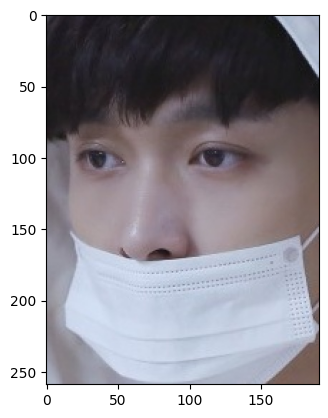

In [15]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_544.jpg')
imgplot = plt.imshow(img)
plt.show()

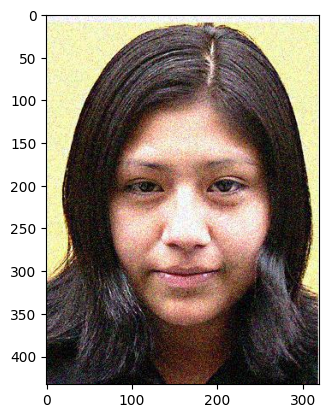

In [16]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_1176.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [17]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [18]:
type(data)

list

In [19]:
len(data)

7553

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
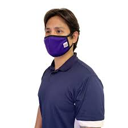

In [20]:
data[0]

In [21]:
type(data[0])

numpy.ndarray

In [22]:
data[0].shape

(128, 128, 3)

In [23]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [24]:
type(X)

numpy.ndarray

In [25]:
type(Y)

numpy.ndarray

In [26]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [27]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [29]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [30]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[224, 219, 216],
        [229, 224, 220],
        [235, 230, 226],
        ...,
        [108, 107, 125],
        [108, 107, 125],
        [108, 107, 125]],

       [[228, 224, 221],
        [232, 226, 223],
        [238, 230, 228],
        ...,
        [108, 107, 125],
        [107, 106, 124],
        [107, 106, 124]],

       [[234, 228, 225],
        [236, 229, 227],
        [240, 231, 229],
        ...,
        [109, 107, 124],
        [108, 106, 123],
        [107, 105, 123]],

       ...,

       [[ 93, 111, 133],
        [ 92, 110, 132],
        [ 91, 109, 130],
        ...,
        [177, 149, 137],
        [175, 147, 135],
        [174, 146, 134]],

       [[ 90, 108, 130],
        [ 89, 107, 129],
        [ 88, 106, 127],
        ...,
        [173, 145, 134],
        [171, 143, 131],
        [170, 142, 130]],

       [[ 89, 107, 129],
        [ 88, 106, 128],
        [ 87, 105, 127],
        ...,
        [172, 144, 133],
        [170, 142, 130],
        [169, 141, 129]]], dtype=uint8)
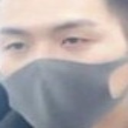

In [31]:
X_train[0]

In [32]:
X_train_scaled[0]

array([[[0.87843137, 0.85882353, 0.84705882],
        [0.89803922, 0.87843137, 0.8627451 ],
        [0.92156863, 0.90196078, 0.88627451],
        ...,
        [0.42352941, 0.41960784, 0.49019608],
        [0.42352941, 0.41960784, 0.49019608],
        [0.42352941, 0.41960784, 0.49019608]],

       [[0.89411765, 0.87843137, 0.86666667],
        [0.90980392, 0.88627451, 0.8745098 ],
        [0.93333333, 0.90196078, 0.89411765],
        ...,
        [0.42352941, 0.41960784, 0.49019608],
        [0.41960784, 0.41568627, 0.48627451],
        [0.41960784, 0.41568627, 0.48627451]],

       [[0.91764706, 0.89411765, 0.88235294],
        [0.9254902 , 0.89803922, 0.89019608],
        [0.94117647, 0.90588235, 0.89803922],
        ...,
        [0.42745098, 0.41960784, 0.48627451],
        [0.42352941, 0.41568627, 0.48235294],
        [0.41960784, 0.41176471, 0.48235294]],

       ...,

       [[0.36470588, 0.43529412, 0.52156863],
        [0.36078431, 0.43137255, 0.51764706],
        [0.35686275, 0

**Building a Convolutional Neural Networks (CNN)**

In [33]:
import tensorflow as tf
from tensorflow import keras

In [34]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [38]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=20)

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9879 - loss: 0.0362 - val_acc: 0.9273 - val_loss: 0.3921
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9800 - loss: 0.0601 - val_acc: 0.9372 - val_loss: 0.2851
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9877 - loss: 0.0365 - val_acc: 0.9388 - val_loss: 0.3178
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9903 - loss: 0.0329 - val_acc: 0.9190 - val_loss: 0.4200
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9838 - loss: 0.0469 - val_acc: 0.9074 - val_loss: 0.3744
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9864 - loss: 0.0370 - val_acc: 0.9388 - val_loss: 0.4099
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9862 - loss: 0.0369 - val_acc: 0.9223 - val_loss: 0.3521
Epoch 8/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9890 - loss: 0.0358 - val_acc: 0.9289 - val_loss: 0.3686
Epoch 9/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/

**Model Evaluation**

In [39]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9305 - loss: 0.4229
Test Accuracy = 0.9305095672607422


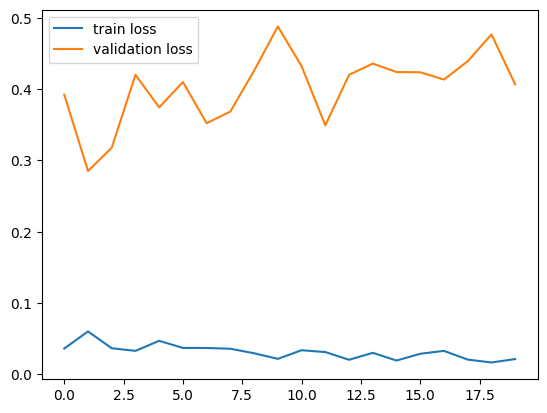

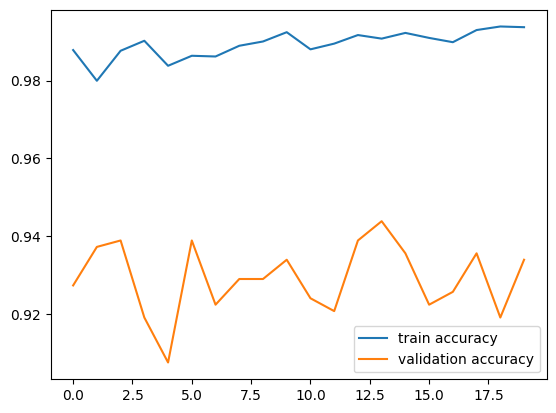

In [40]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/data/without_mask/without_mask_123.jpg


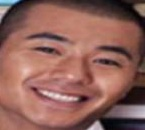

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
[[0.46198973 0.33012938]]
0
The person in the image is not wearing a mask


In [42]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

In [43]:
model.save("face_mask_model.h5")